In [1]:
from pathlib import Path
import json
import shutil
import urllib.request
import zipfile
from datetime import datetime
from typing import Any

from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path

# 当前 Jupyter 的工作目录
CURRENT_DIR = Path.cwd()

print("当前工作目录：", CURRENT_DIR)

# 情况 1：如果当前目录就是 scripts，则项目根目录是它的上一级 YOLO
if CURRENT_DIR.name == "scripts":
    ROOT_DIR = CURRENT_DIR.parent

# 情况 2：如果当前目录下有 scripts、datasets、outputs，说明当前目录就是 YOLO
elif (CURRENT_DIR / "scripts").exists():
    ROOT_DIR = CURRENT_DIR

# 情况 3：如果 VSCode 把工作目录设置到了别的地方，手动兜底
else:
    # 根据你的截图，项目根目录应该是 d:/code/yolo
    ROOT_DIR = Path(r"d:\code\yolo")

print("项目根目录：", ROOT_DIR)

# 数据集目录
DATASETS_DIR = ROOT_DIR / "datasets"
COCO128_DIR = DATASETS_DIR / "coco128"
COCO128_ZIP = DATASETS_DIR / "coco128.zip"

# COCO128 图片目录
IMAGE_DIR = COCO128_DIR / "images" / "train2017"

# 输出目录
OUTPUT_DIR = ROOT_DIR / "outputs" / "stage1_coco128_inference"
ANNOTATED_DIR = OUTPUT_DIR / "annotated_images"
JSON_DIR = OUTPUT_DIR / "json_results"

# 创建需要的目录
for path in [
    DATASETS_DIR,
    OUTPUT_DIR,
    ANNOTATED_DIR,
    JSON_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("数据集目录：", DATASETS_DIR)
print("COCO128 目录：", COCO128_DIR)
print("输出目录：", OUTPUT_DIR)
print("可视化结果目录：", ANNOTATED_DIR)
print("JSON 结果目录：", JSON_DIR)

当前工作目录： d:\code\yolo\scripts
项目根目录： d:\code\yolo
数据集目录： d:\code\yolo\datasets
COCO128 目录： d:\code\yolo\datasets\coco128
输出目录： d:\code\yolo\outputs\stage1_coco128_inference
可视化结果目录： d:\code\yolo\outputs\stage1_coco128_inference\annotated_images
JSON 结果目录： d:\code\yolo\outputs\stage1_coco128_inference\json_results


In [4]:
COCO128_URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip"


def download_coco128():
    if IMAGE_DIR.exists() and len(list(IMAGE_DIR.glob("*.jpg"))) > 0:
        print("[OK] COCO128 数据集已存在：", IMAGE_DIR)
        return

    if not COCO128_ZIP.exists():
        print("[下载] 开始下载 COCO128 ...")
        urllib.request.urlretrieve(COCO128_URL, COCO128_ZIP)
        print("[OK] 下载完成：", COCO128_ZIP)
    else:
        print("[OK] 压缩包已存在：", COCO128_ZIP)

    if COCO128_DIR.exists():
        shutil.rmtree(COCO128_DIR)

    print("[解压] 开始解压 COCO128 ...")
    with zipfile.ZipFile(COCO128_ZIP, "r") as zip_ref:
        zip_ref.extractall(DATASETS_DIR)

    if not IMAGE_DIR.exists():
        raise FileNotFoundError(f"未找到图片目录：{IMAGE_DIR}")

    print("[OK] COCO128 准备完成：", IMAGE_DIR)


download_coco128()

[下载] 开始下载 COCO128 ...
[OK] 下载完成： d:\code\yolo\datasets\coco128.zip
[解压] 开始解压 COCO128 ...
[OK] COCO128 准备完成： d:\code\yolo\datasets\coco128\images\train2017


In [5]:
image_paths = sorted(
    list(IMAGE_DIR.glob("*.jpg")) +
    list(IMAGE_DIR.glob("*.jpeg")) +
    list(IMAGE_DIR.glob("*.png"))
)

print("图片数量：", len(image_paths))
print("前 5 张图片：")

for path in image_paths[:5]:
    print(path.name)

图片数量： 128
前 5 张图片：
000000000009.jpg
000000000025.jpg
000000000030.jpg
000000000034.jpg
000000000036.jpg


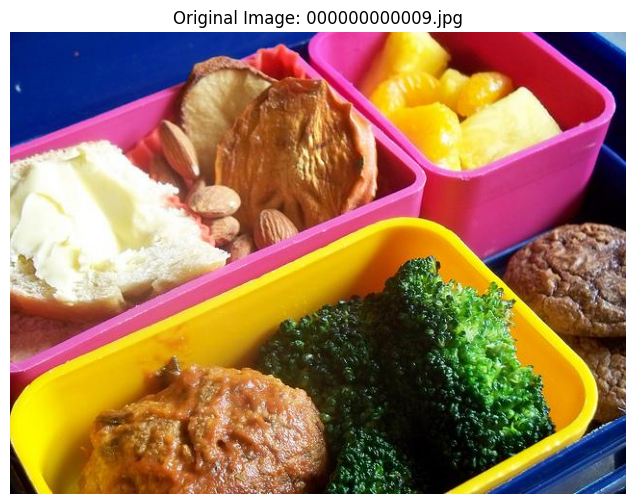

In [6]:
sample_image_path = image_paths[0]

img = Image.open(sample_image_path)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Original Image: {sample_image_path.name}")
plt.show()

In [7]:
MODEL_CANDIDATES = [
    "yolo26n.pt",
]


def load_model(model_candidates):
    last_error = None

    for model_name in model_candidates:
        try:
            print(f"[模型] 尝试加载：{model_name}")
            model = YOLO(model_name)
            print(f"[OK] 模型加载成功：{model_name}")
            return model, model_name
        except Exception as exc:
            print(f"[失败] {model_name} 加载失败")
            last_error = exc

    raise RuntimeError(f"所有模型均加载失败，最后错误：{last_error}")


model, model_name = load_model(MODEL_CANDIDATES)

print("当前使用模型：", model_name)
print("模型类别数量：", len(model.names))
print("前 10 个类别：", list(model.names.items())[:10] if isinstance(model.names, dict) else model.names[:10])

[模型] 尝试加载：yolo26n.pt
[OK] 模型加载成功：yolo26n.pt
当前使用模型： yolo26n.pt
模型类别数量： 80
前 10 个类别： [(0, 'person'), (1, 'bicycle'), (2, 'car'), (3, 'motorcycle'), (4, 'airplane'), (5, 'bus'), (6, 'train'), (7, 'truck'), (8, 'boat'), (9, 'traffic light')]


In [8]:
CONF_THRESHOLD = 0.25
IMAGE_SIZE = 640

single_results = model.predict(
    source=str(sample_image_path),
    imgsz=IMAGE_SIZE,
    conf=CONF_THRESHOLD,
    verbose=False
)

single_result = single_results[0]

print("图片：", sample_image_path.name)
print("检测目标数量：", len(single_result.boxes))

图片： 000000000009.jpg
检测目标数量： 5


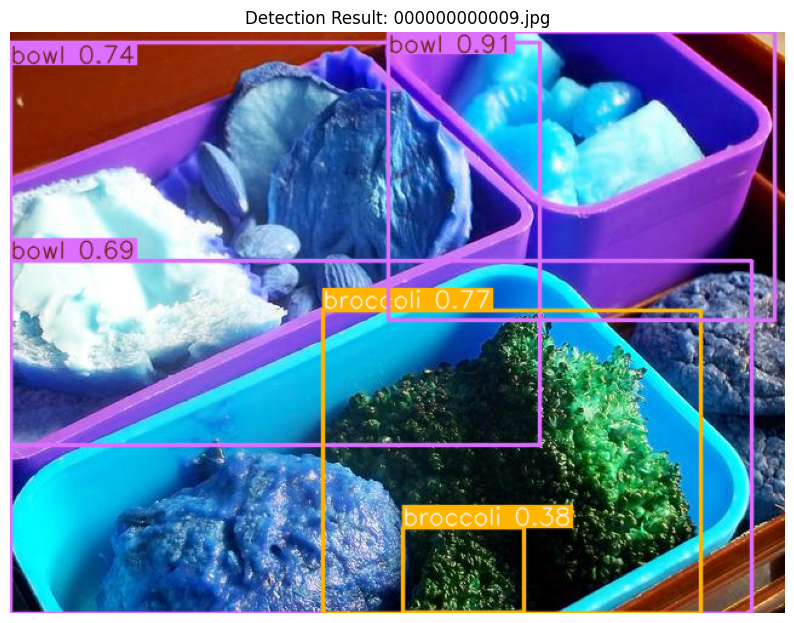

In [9]:
annotated_array = single_result.plot()

plt.figure(figsize=(10, 8))
plt.imshow(annotated_array)
plt.axis("off")
plt.title(f"Detection Result: {sample_image_path.name}")
plt.show()

In [10]:
def get_class_name(model, class_id):
    names = model.names

    if isinstance(names, dict):
        return names.get(class_id, str(class_id))

    if isinstance(names, list) and 0 <= class_id < len(names):
        return names[class_id]

    return str(class_id)


for i, box in enumerate(single_result.boxes):
    class_id = int(box.cls[0].item())
    class_name = get_class_name(model, class_id)
    confidence = float(box.conf[0].item())
    xyxy = box.xyxy[0].cpu().tolist()

    print(f"目标 {i + 1}")
    print("类别 ID：", class_id)
    print("类别名称：", class_name)
    print("置信度：", round(confidence, 4))
    print("边界框 xyxy：", [round(x, 2) for x in xyxy])
    print("-" * 50)

目标 1
类别 ID： 45
类别名称： bowl
置信度： 0.912
边界框 xyxy： [312.28, 0.0, 631.05, 238.78]
--------------------------------------------------
目标 2
类别 ID： 50
类别名称： broccoli
置信度： 0.7697
边界框 xyxy： [258.96, 230.78, 570.21, 480.0]
--------------------------------------------------
目标 3
类别 ID： 45
类别名称： bowl
置信度： 0.7419
边界框 xyxy： [0.0, 9.12, 437.96, 341.76]
--------------------------------------------------
目标 4
类别 ID： 45
类别名称： bowl
置信度： 0.6946
边界框 xyxy： [0.0, 189.79, 612.4, 480.0]
--------------------------------------------------
目标 5
类别 ID： 50
类别名称： broccoli
置信度： 0.3751
边界框 xyxy： [324.34, 409.77, 424.78, 479.78]
--------------------------------------------------


In [11]:
def result_to_dict(model, result):
    image_path = Path(result.path)
    detections = []

    for box in result.boxes:
        class_id = int(box.cls[0].item())
        confidence = float(box.conf[0].item())

        xyxy = box.xyxy[0].cpu().tolist()
        xywh = box.xywh[0].cpu().tolist()

        detection = {
            "class_id": class_id,
            "class_name": get_class_name(model, class_id),
            "confidence": round(confidence, 6),
            "bbox_xyxy": [round(float(x), 3) for x in xyxy],
            "bbox_xywh": [round(float(x), 3) for x in xywh],
        }

        detections.append(detection)

    return {
        "image_name": image_path.name,
        "image_path": str(image_path),
        "image_width": int(result.orig_shape[1]),
        "image_height": int(result.orig_shape[0]),
        "num_detections": len(detections),
        "detections": detections,
    }


single_result_dict = result_to_dict(model, single_result)

single_result_dict

{'image_name': '000000000009.jpg',
 'image_path': 'd:\\code\\yolo\\datasets\\coco128\\images\\train2017\\000000000009.jpg',
 'image_width': 640,
 'image_height': 480,
 'num_detections': 5,
 'detections': [{'class_id': 45,
   'class_name': 'bowl',
   'confidence': 0.911984,
   'bbox_xyxy': [312.278, 0.0, 631.05, 238.784],
   'bbox_xywh': [471.664, 119.392, 318.772, 238.784]},
  {'class_id': 50,
   'class_name': 'broccoli',
   'confidence': 0.769666,
   'bbox_xyxy': [258.959, 230.779, 570.214, 480.0],
   'bbox_xywh': [414.586, 355.389, 311.255, 249.221]},
  {'class_id': 45,
   'class_name': 'bowl',
   'confidence': 0.741884,
   'bbox_xyxy': [0.0, 9.122, 437.958, 341.763],
   'bbox_xywh': [218.979, 175.443, 437.958, 332.641]},
  {'class_id': 45,
   'class_name': 'bowl',
   'confidence': 0.694564,
   'bbox_xyxy': [0.0, 189.79, 612.395, 480.0],
   'bbox_xywh': [306.198, 334.895, 612.395, 290.21]},
  {'class_id': 50,
   'class_name': 'broccoli',
   'confidence': 0.375094,
   'bbox_xyxy': [32

In [12]:
single_json_path = JSON_DIR / f"{sample_image_path.stem}.json"
single_annotated_path = ANNOTATED_DIR / sample_image_path.name

# 保存 JSON
with open(single_json_path, "w", encoding="utf-8") as f:
    json.dump(single_result_dict, f, ensure_ascii=False, indent=2)

# 保存可视化图片
single_result.save(filename=str(single_annotated_path))

print("单张 JSON 已保存：", single_json_path)
print("单张可视化图片已保存：", single_annotated_path)

单张 JSON 已保存： d:\code\yolo\outputs\stage1_coco128_inference\json_results\000000000009.json
单张可视化图片已保存： d:\code\yolo\outputs\stage1_coco128_inference\annotated_images\000000000009.jpg


In [13]:
MAX_IMAGES = 20

if MAX_IMAGES is None:
    batch_image_paths = image_paths
else:
    batch_image_paths = image_paths[:MAX_IMAGES]

print("本次批量识别图片数量：", len(batch_image_paths))

本次批量识别图片数量： 20


In [14]:
all_detection_results = []

for index, image_path in enumerate(batch_image_paths, start=1):
    print(f"[{index}/{len(batch_image_paths)}] 正在识别：{image_path.name}")

    results = model.predict(
        source=str(image_path),
        imgsz=IMAGE_SIZE,
        conf=CONF_THRESHOLD,
        verbose=False
    )

    result = results[0]

    # 保存可视化图片
    annotated_save_path = ANNOTATED_DIR / image_path.name
    result.save(filename=str(annotated_save_path))

    # 保存 JSON
    result_dict = result_to_dict(model, result)
    json_save_path = JSON_DIR / f"{image_path.stem}.json"

    with open(json_save_path, "w", encoding="utf-8") as f:
        json.dump(result_dict, f, ensure_ascii=False, indent=2)

    all_detection_results.append(result_dict)

print("[OK] 批量识别完成")

[1/20] 正在识别：000000000009.jpg
[2/20] 正在识别：000000000025.jpg
[3/20] 正在识别：000000000030.jpg
[4/20] 正在识别：000000000034.jpg
[5/20] 正在识别：000000000036.jpg
[6/20] 正在识别：000000000042.jpg
[7/20] 正在识别：000000000049.jpg
[8/20] 正在识别：000000000061.jpg
[9/20] 正在识别：000000000064.jpg
[10/20] 正在识别：000000000071.jpg
[11/20] 正在识别：000000000072.jpg
[12/20] 正在识别：000000000073.jpg
[13/20] 正在识别：000000000074.jpg
[14/20] 正在识别：000000000077.jpg
[15/20] 正在识别：000000000078.jpg
[16/20] 正在识别：000000000081.jpg
[17/20] 正在识别：000000000086.jpg
[18/20] 正在识别：000000000089.jpg
[19/20] 正在识别：000000000092.jpg
[20/20] 正在识别：000000000094.jpg
[OK] 批量识别完成


In [15]:
summary = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "model_name": model_name,
    "image_size": IMAGE_SIZE,
    "confidence_threshold": CONF_THRESHOLD,
    "num_images": len(all_detection_results),
    "num_total_detections": sum(item["num_detections"] for item in all_detection_results),
    "results": all_detection_results,
}

summary_path = OUTPUT_DIR / "all_detections.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("汇总结果已保存：", summary_path)

汇总结果已保存： d:\code\yolo\outputs\stage1_coco128_inference\all_detections.json


In [16]:
for item in all_detection_results:
    print(
        item["image_name"],
        "检测目标数：",
        item["num_detections"]
    )

000000000009.jpg 检测目标数： 5
000000000025.jpg 检测目标数： 2
000000000030.jpg 检测目标数： 2
000000000034.jpg 检测目标数： 1
000000000036.jpg 检测目标数： 2
000000000042.jpg 检测目标数： 1
000000000049.jpg 检测目标数： 6
000000000061.jpg 检测目标数： 3
000000000064.jpg 检测目标数： 4
000000000071.jpg 检测目标数： 1
000000000072.jpg 检测目标数： 2
000000000073.jpg 检测目标数： 1
000000000074.jpg 检测目标数： 6
000000000077.jpg 检测目标数： 3
000000000078.jpg 检测目标数： 1
000000000081.jpg 检测目标数： 1
000000000086.jpg 检测目标数： 2
000000000089.jpg 检测目标数： 9
000000000092.jpg 检测目标数： 3
000000000094.jpg 检测目标数： 2


In [17]:
from collections import Counter

class_counter = Counter()

for item in all_detection_results:
    for det in item["detections"]:
        class_counter[det["class_name"]] += 1

print("识别类别统计：")

for class_name, count in class_counter.most_common():
    print(class_name, count)

识别类别统计：
person 14
knife 7
giraffe 4
car 4
bowl 3
broccoli 2
dog 2
horse 2
elephant 2
clock 2
motorcycle 2
vase 1
potted plant 1
zebra 1
umbrella 1
truck 1
train 1
bicycle 1
airplane 1
oven 1
microwave 1
fork 1
cake 1
dining table 1


已保存可视化结果数量： 20


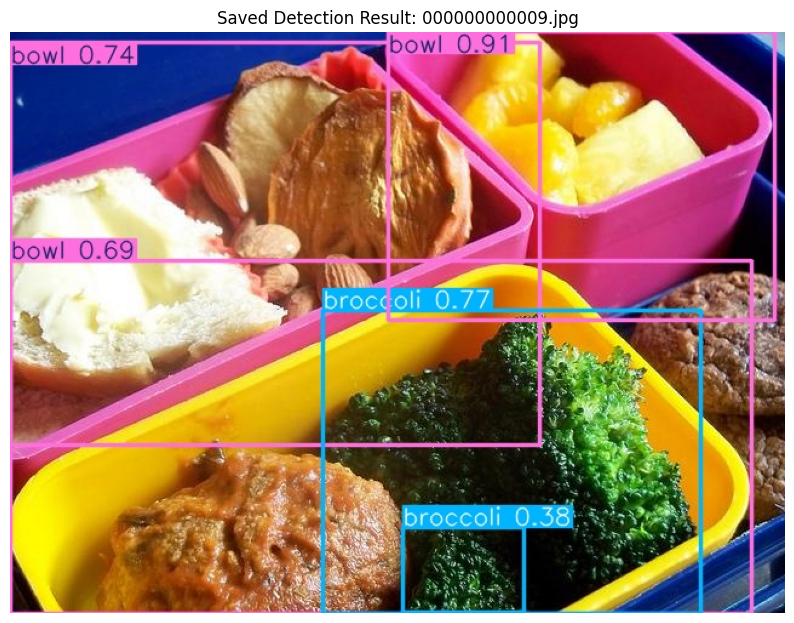

In [18]:
result_images = sorted(ANNOTATED_DIR.glob("*.jpg"))

print("已保存可视化结果数量：", len(result_images))

preview_path = result_images[0]
preview_img = Image.open(preview_path)

plt.figure(figsize=(10, 8))
plt.imshow(preview_img)
plt.axis("off")
plt.title(f"Saved Detection Result: {preview_path.name}")
plt.show()